# 05. Status update 1: presentation deck

**Student:** Nikola Baburov  **Course:** Individual Project, Semester 6  **Date:** 27 May 2026

> **How to use this notebook.** This is the *presentation* version: one idea per section, plain language, visuals first. The detailed technical record lives in earlier project notebooks. Numbers here are frozen as of 27 May 2026; run top-to-bottom to regenerate the figures.

**The story in one line:** I am teaching a model to spot a specific price pattern (a "Fair Value Gap") on stock data, and to say *how confident* it is, instead of hand-coding every rule a trader uses.

### What this maps to (semester 6 learning outcomes)

| Outcome | What it asks | Evidenced in |
|---|---|---|
| **LO1 Data Preparation** | inspect, clean, transform, schema, prevent leakage | Sec 3, 4, 5, 6 (source choice, automatic labelling, gold-set check, leakage test) |
| **LO2 Data Analysis & Model Engineering** | technique rationale, train/val/test, metrics, error analysis, baselines, ablations | Sec 7, 8, 9, 10 (windows, features, four models, sweeps, multi-seed) |
| **LO3 Professional Standard** | own the problem, pick methodology, advise under uncertainty | Sec 2, 3.5, 11 (why ML earns its keep, rejected paths with evidence, honest limitation) |
| **LO4 Personal Leadership** | set + execute + adjust long-term goals, reflect on adjustments | Sec 12 (reflection on the XGBoost-over-DL result and the dropped tricks) |


---
## 1. What am I doing?

I build a system that reads stock candlestick data and **automatically marks "Fair Value Gap" zones**, each with a confidence score.

- **Input:** SPY hourly candles (open, high, low, close, volume). SPY is a fund that tracks the US S&P 500 index.
- **Output:** labelled zones on the chart + a confidence number, drawn as overlays.
- **Not** price prediction. I never guess tomorrow's price. I detect a *structure* that is already forming.

The system behaves like a smoke detector rather than a fortune teller. It flags a structure that is already forming in past candles. It does not forecast the next price.

In [1]:
# === Minimal setup (self-contained: no project imports, no data files) ===
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"

BULL, BEAR, NEUTRAL, TEXT = "#26a69a", "#ef5350", "#95a5a6", "#37474f"
SPLIT = {"train": "#1e88e5", "val": "#fb8c00", "test": "#43a047"}

def synth(opens, highs, lows, closes, names):
    return pd.DataFrame({"open": opens, "high": highs, "low": lows, "close": closes}, index=names)

def candle(sdf):
    return go.Candlestick(x=list(sdf.index), open=sdf["open"], high=sdf["high"],
        low=sdf["low"], close=sdf["close"],
        increasing_line_color=BULL, decreasing_line_color=BEAR, showlegend=False)

def style(fig, title, height=440):
    fig.update_layout(title=title, height=height, template="plotly_white",
        xaxis_rangeslider_visible=False, yaxis_title="Price")
    fig.update_xaxes(type="category")
    return fig

print("Setup ready. No external data needed for this deck.")

Setup ready. No external data needed for this deck.


In [2]:
# Figure 1, anatomy of a candle (the only "finance" you need today).
demo = synth([100, 106], [108, 108], [98, 100], [105, 101], ["up hour", "down hour"])
fig = go.Figure(candle(demo))
fig.add_annotation(x="up hour", y=108, ax=110, ay=-45, text="<b>wick</b> = the high/low reached", showarrow=True, arrowhead=2)
fig.add_annotation(x="up hour", y=102.5, ax=150, ay=0, text="<b>body</b> = open to close", showarrow=True, arrowhead=2)
style(fig, "Figure 1. One candle = one hour. Green closed up, red closed down.", height=420)
fig.show()

**Figure 1.** Each candle summarises one hour of trading into five numbers. Green means price closed higher than it opened, red means it closed lower. Every model in this project reads a stream of these candles, nothing else.

---
## 2. Is this just an algorithm?

Fair. A **raw** Fair Value Gap (FVG) is pure geometry: a price gap across three candles. A simple `if` rule catches every one. I proved this: my rule agreed with my own hand-marking **perfectly (Cohen's kappa = 1.0)**. So detecting *raw* gaps needs no machine learning.

**But raw gaps are not the real target.** Most of them are noise. What a trader actually cares about is a **Valid** FVG: a gap that also passes 6 quality checks (a 3-candle gap exists, the reaction candle closes back into the gap, an S/R level sits inside the zone, the gap is on the trend side of the recent swing midpoint, a recent break of market structure preceded it, and the gap is still unmitigated). That decision is fuzzy, context-dependent, and rare (about **3%** of bars).

So why use ML if the rule itself works? Two reasons:

- **Confidence, not yes/no.** The rule gives a binary verdict. A model gives a probability per zone, which lets me rank gaps, set a threshold per risk appetite, and report uncertainty instead of pretending the call is clean.
- **Learn from price, not from my heuristics.** The 6 checks are *my* reading of the literature. A model can find which gaps actually matter from raw price + a small set of features, and improve as more data arrives. The rule cannot.

The two figures below show the geometry the model has to recognise.

In [3]:
# Figure 2, Bullish FVG: an untraded gap left by a fast move up.
bull = synth([100,101,106],[102,105,110],[99,100,105],[101,104,109],["N-1","N (up)","N+1"])
fig = go.Figure(candle(bull))
y0, y1 = bull["high"].iloc[0], bull["low"].iloc[2]
fig.add_shape(type="rect", x0="N-1", x1="N+1", y0=y0, y1=y1, fillcolor=BULL, opacity=0.22,
              line=dict(color=BULL, width=1.5, dash="dot"))
fig.add_annotation(x="N+1", y=(y0+y1)/2, ax=70, ay=0, text="<b>the gap</b><br>price skipped this zone",
                   showarrow=True, arrowhead=2, font=dict(color="#1b5e20"))
style(fig, "Figure 2. Bullish FVG. The shaded band never traded: price jumped over it.", height=460)
fig.show()

**Figure 2.** A **bull** gap. The middle candle moves up so fast that the shaded price band is skipped entirely. Traders expect price to often return and "fill" that band later.

In [4]:
# Figure 3, Bearish FVG: mirror image, fast move down.
bear = synth([110,109,104],[111,110,106],[108,105,100],[109,106,101],["N-1","N (down)","N+1"])
fig = go.Figure(candle(bear))
y0, y1 = bear["high"].iloc[2], bear["low"].iloc[0]
fig.add_shape(type="rect", x0="N-1", x1="N+1", y0=y0, y1=y1, fillcolor=BEAR, opacity=0.22,
              line=dict(color=BEAR, width=1.5, dash="dot"))
fig.add_annotation(x="N+1", y=(y0+y1)/2, ax=70, ay=0, text="<b>the gap</b><br>price skipped this zone",
                   showarrow=True, arrowhead=2, font=dict(color="#b71c1c"))
style(fig, "Figure 3. Bearish FVG. Mirror of Figure 2: a fast sell-off skips the band.", height=460)
fig.show()

**Figure 3.** A **bear** gap, the mirror case. The 6 "valid" checks (a confirming reaction candle, a recent break of market structure, and others) decide which of these gaps are worth flagging. Those checks are what the model learns to reproduce and score.

---
## 3. What data do I use?

- **SPY hourly candles, 2016 to 2025** (about 17,500 hours of trading).
- Source: **Alpaca** (official market-data API). I rejected **yfinance** because it only serves the last 730 days, and I need a decade.
- I split the timeline **by date, never randomly**. Training on later years and testing on earlier ones would leak the future into the model:

| Split | Years | Role |
|---|---|---|
| **Train** | 2016-2021 | model learns here |
| **Validation** | 2022 | tune settings here |
| **Test** | 2023-2025 | judged here, untouched until the end |

In [5]:
# Figure 4, the temporal split as a simple timeline (no random shuffling).
years = list(range(2016, 2026))
role  = ["train"]*6 + ["val"] + ["test"]*3   # 2016-21 train, 2022 val, 2023-25 test
fig = go.Figure()
for r, c in SPLIT.items():
    xs = [y for y, rr in zip(years, role) if rr == r]
    fig.add_bar(x=xs, y=[1]*len(xs), name=r, marker_color=c, width=0.9)
fig.update_layout(title="Figure 4. Time-ordered split. Train on the past, test on the most recent years.",
                  template="plotly_white", height=240, barmode="stack",
                  yaxis=dict(visible=False), legend_title="")
fig.show()

**Figure 4.** The split respects time. The model is judged on 2023-2025, data it never saw while learning, which is the only honest test for time series.

---
## 3.5 Key decisions and rejected paths

Four rejected paths shaped this one. Each is logged with reproducible evidence:

| Decision | Rejected option | Reason | Source |
|---|---|---|---|
| **Data source** | yfinance | Hard 730-day cap on hourly history. Need 2016+. | Empirical test, 8 May 2026 |
| **FVG labelling** | `smartmoneyconcepts` library (v0.0.27) | 1-bar lookahead leakage (`shift(-1)` in FVG detector, upstream PR unmerged). | Source-code audit |
| **Neural net training device** | Apple MPS GPU | Gradient-kernel bug in torch 2.11 corrupts LSTM training. CPU is correct, ~3x slower. | Reproduced, 12 May 2026 |
| **Loss + threshold tuning** | Focal loss, tuned cut-off | Both scored *below* plain weighted cross-entropy on test. Dropped. | 5-seed sweep |



---
## 4. How do I label the data?

**Automatically.** I wrote a labeller (`ValidFVGLabeller`) that scans every candle and assigns one of three outcomes: `none`, `bull`, or `bear`. It is a **single ternary label per bar**, not one label per criterion: the 6 checks combine into a yes/no inside the labeller, and only the final verdict is stored. The model never sees the criteria directly; it learns to predict the verdict from the price window. Two design rules matter:

- **No looking ahead.** The label for a candle uses only information available *at that moment* (it is emitted at bar N+2, the first point where all checks are knowable). A test in the code enforces this, because a single peek at the future would silently inflate every result.
- **Vectorised, no loops.** It labels 10 years of data in well under a second.

Doing this by hand for 17,500 candles is impossible. So the labels are machine-made, which raises an obvious question: *how do I know the machine is right?*

---
## 5. How do I check the automatic labels? (Gold annotation)

I hand-labelled a **gold set of 75 candles** myself, looking at the charts with no hint from the algorithm (to avoid bias). Then I compared my labels to the labeller's.

- Agreement: **Cohen's kappa = 1.0** (perfect; kappa is an agreement score where 1.0 is perfect and 0 is chance-level).

What the kappa actually shows: on the same 75 candles, the 6-criteria rule and my unaided human judgment agreed on every single label. So the rule encodes the call I would make by hand. That is what the model is then trained to reproduce, faster and with a confidence score attached.

## 6. Why bother with the gold set?

Because the model trains on the labeller's output. If I only ever scored *model vs labeller*, I would be measuring "did the model copy my rule", not "is the model correct". The gold set is the **only label not made by my own code**, so it is an independent reality check. It is what lets me claim the labels match a *human*, not only my own script. It also answers the obvious "if the rule works, why use ML?" question. The rule defines the target. The model adds the confidence score and learns from raw price instead of from my heuristics.

---
## 7. How do I prepare data for the different models?

Everyone shares the same front half, then it splits into **two shapes** depending on the model.

```
download  ->  resample to hourly  ->  label (ValidFVG)  ->  split by date  ->  slide a 60-candle window
                                                                                     |
                                        +--------------------------------------------+
                                        |                                            |
                            raw 60 x 5 sequence                          35 engineered numbers
                            (LSTM, CNN-LSTM)                             (XGBoost)
```

- A **window** = the last 60 hours of candles, used to label the final hour.
- **Stride** = how many hours I jump forward to grab the next window. Stride 1 means each new window starts one hour later than the last, so neighbouring windows share 59 of their 60 candles. Stride 60 means I jump a full window forward, so no two windows share any candle.
- **Training uses stride 1** (heavy overlap squeezes out the most labelled examples from the same data). **Validation and test use stride 60** (no overlap, so each test score is on genuinely fresh windows, no double-counting).
- Neural nets eat the **raw sequence** and learn their own features. XGBoost cannot, so it gets a **flat list of 35 numbers** per window (next section).

Same data, same labels, same splits for every model, so the comparison is fair.

---
## 8. Why engineer features, and what do they do?

A tree model (XGBoost) cannot read a raw 60x5 sequence, it needs a flat row of numbers. So for each window I compute **35 features**, each one a summary a trader might glance at. All are **strictly causal**: they use only candles `t-59 ... t`, never the future.

| Group | Count | What it captures (plain language) |
|---|---|---|
| Returns | 8 | how much price moved over 1, 5, 10, 20, 60 hours |
| Volatility | 5 | how jumpy/wide the recent candles are (ATR, ranges) |
| Momentum/trend | 7 | is it trending up or down (RSI, MACD, slope, moving averages) |
| Volume | 5 | is trading unusually heavy or light (volume z-scores, spikes) |
| FVG geometry | 10 | the gap itself: size, location, whether price reacted in it |

The last group hands the model the gap geometry directly. That is partly *why* the tree wins: I gave it the answer-shaped clues, while the neural nets must discover them from scratch.

---
## 9. What models have I tried, and how did they score?

I went from simple to complex, judging all on the **same test set** with **Macro F1 on the rare gap classes** (accuracy is useless when 97% of candles are `none`, so I score the minority classes).

| Model | What it is | Test Macro F1 |
|---|---|---|
| **Naive (majority)** | always guess `none` (the floor) | 0.328 |
| **LSTM** | recurrent neural net, reads the sequence | 0.599 ± 0.025 |
| **CNN-LSTM** | adds a convolution to spot local shapes | 0.614 ± 0.021 |
| **XGBoost** | gradient-boosted trees on the 35 features | **0.721 ± 0.001** |

Higher is better; ± is the spread across 5 random seeds.

In [6]:
# Figure 5, model comparison with seed spread (frozen from docs/models-status.md).
models = ["Naive\n(floor)", "LSTM", "CNN-LSTM", "XGBoost"]
f1     = [0.328, 0.599, 0.614, 0.721]
err    = [0.0,   0.025, 0.021, 0.001]
colors = [NEUTRAL, SPLIT["val"], "#8e44ad", SPLIT["test"]]
fig = go.Figure(go.Bar(x=models, y=f1, marker_color=colors,
    error_y=dict(type="data", array=err, visible=True),
    text=[f"{v:.3f}" for v in f1], textposition="outside"))
fig.update_layout(title="Figure 5. Test Macro F1 by model (5-seed mean, error bar = std).",
    template="plotly_white", height=440, yaxis=dict(title="Macro F1", range=[0, 0.85]))
fig.show()

**Figure 5.** XGBoost reaches 0.721, above the two deep-learning models at 0.599 and 0.614, and well above the 0.328 floor. Its spread across the five seeds is the smallest at ±0.001, so it is also the most stable choice.

---
## 10. Did I tune the models? (Sweeps and what they revealed)

Yes. A single lucky run proves nothing, so I ran systematic searches:

- **Hyperparameter search (Optuna):** ~50 trials per model to find good settings automatically.
- **Multi-seed (5 seeds):** repeat each model 5 times to measure stability, not luck.
- **Threshold sweep:** try different confidence cut-offs for calling a gap.
- **Window sweep:** test how many past hours to feed in.
- **Bootstrap confidence intervals:** 1,000 resamples to put error bars on the scores.

**What I found out:**

1. **XGBoost dominates** (0.721 vs 0.599-0.614). The dataset is effectively tiny: the windows overlap so heavily that there are only about **86-117 independent examples**. In that small-data regime, gradient-boosted trees beating neural nets is the expected result, not a surprise.
2. **Fancier tricks did *not* help.** Focal loss and threshold tuning both scored *worse* than the plain baseline, so I dropped them.
3. **Stability matters.** XGBoost's ±0.001 across seeds makes it the trustworthy choice for the demo.

This is exactly why XGBoost is my **mandatory control**: if a complex neural net cannot beat boosted trees, the extra complexity is not justified.

---
## 11. Where the project stands

- **Done:** leakage-safe data pipeline, automatic + gold-checked labels, four models compared with full rigor (sweeps, seeds, confidence intervals), an offline inspection tool and a paper-trading harness.
- **Best model:** XGBoost, Macro F1 = 0.721 ± 0.001 on 2023-2025.
- **Honest limitation:** the model is trained to mimic my own rule, so at best it matches the rule. The gold set keeps that claim honest, but the real contribution is the *confidence scoring* and the *leakage-safe, reproducible* setup, not beating the rule.

---
## 11a. Inspection tool: how I look at a model's decisions

The inspection tool replays the test set candle-by-candle and produces, for every hour, the model's three class probabilities (`none` / `bull` / `bear`). I plot them as a strip alongside the *actual* labels, so failures are visible at a glance: false positives, missed gaps, low-confidence correct calls.

This is what tells me *where* a model fails, not just its average F1.


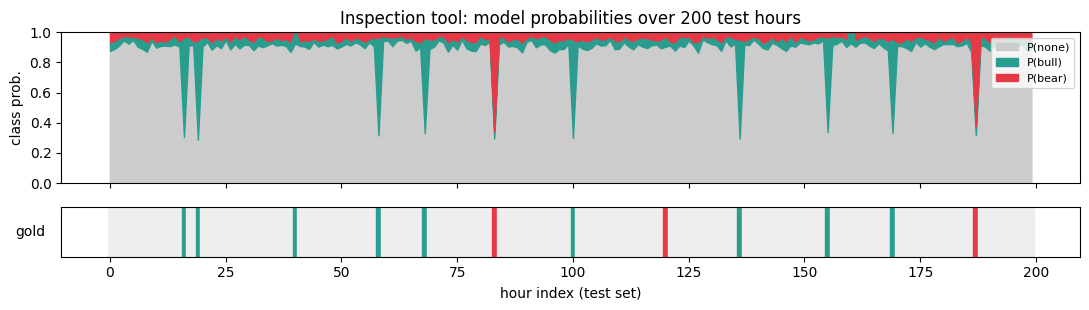

In [7]:
# Figure 6 (mock): inspection-tool probability strip vs gold labels.
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(7)
T = 200
p_bull = np.clip(0.02 + 0.6*(rng.random(T)>0.96) + 0.05*rng.random(T), 0, 1)
p_bear = np.clip(0.02 + 0.6*(rng.random(T)>0.97) + 0.05*rng.random(T), 0, 1)
p_none = np.clip(1 - p_bull - p_bear, 0, 1)
gold = np.zeros(T, int)
gold[p_bull>0.4] = 1
gold[p_bear>0.4] = 2
# inject 2 misses + 1 false positive
gold[40]=1; p_bull[40]=0.15
gold[120]=2; p_bear[120]=0.18
p_bull[160]=0.7

fig, ax = plt.subplots(2,1, figsize=(11,3.2), sharex=True,
                       gridspec_kw={'height_ratios':[3,1]})
ax[0].fill_between(range(T), 0, p_none, color='#cccccc', label='P(none)')
ax[0].fill_between(range(T), p_none, p_none+p_bull, color='#2a9d8f', label='P(bull)')
ax[0].fill_between(range(T), p_none+p_bull, 1, color='#e63946', label='P(bear)')
ax[0].set_ylim(0,1); ax[0].set_ylabel('class prob.'); ax[0].legend(loc='upper right', fontsize=8)
ax[0].set_title('Inspection tool: model probabilities over 200 test hours')

cmap = {0:'#eeeeee', 1:'#2a9d8f', 2:'#e63946'}
for t,g in enumerate(gold):
    ax[1].axvspan(t-0.5, t+0.5, color=cmap[int(g)])
ax[1].set_yticks([]); ax[1].set_xlabel('hour index (test set)')
ax[1].set_ylabel('gold', rotation=0, labelpad=22, va='center')
plt.tight_layout(); plt.show()


**Figure 6.** A 200-hour slice of inspection output. Top: per-hour class probabilities. Bottom: gold labels. Confident correct calls line up; rare gaps with low probability and isolated high-confidence spikes on `none` are the exact cases I drill into.


---
## 11b. Paper-trading harness: closing the loop on live data

The harness wires the trained model into Alpaca's live SPY stream. It is *dry-run by default*: it produces decisions and logs, but never submits orders. The point is to confirm the offline pipeline survives contact with real ticks.

```
Alpaca WS stream  ->  window builder  ->  model  ->  decision  ->  logger (JSONL)
                       (last 60 H1)        |               |
                                           +-> probability  +-> slippage model
```

Every component of the harness is unit-tested (47 tests). A replay module lets me re-run any logged session offline against a different model checkpoint.


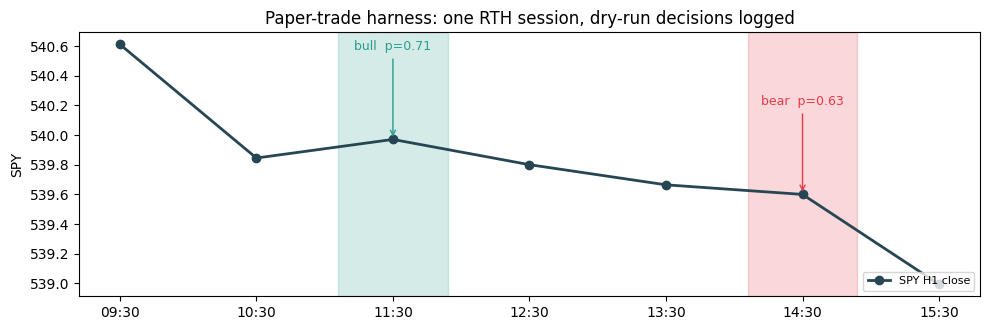

In [8]:
# Figure 7 (mock): one paper-trade session timeline.
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(3)
hours = np.arange(7)  # 09:30-15:30 ET
price = 540 + np.cumsum(rng.normal(0, 0.3, len(hours)))
sig_t = [2, 5]
sig_kind = ['bull', 'bear']
sig_conf = [0.71, 0.63]

fig, ax = plt.subplots(figsize=(10,3.4))
ax.plot(hours, price, color='#264653', lw=2, marker='o', label='SPY H1 close')
for t,k,c in zip(sig_t, sig_kind, sig_conf):
    col = '#2a9d8f' if k=='bull' else '#e63946'
    ax.axvspan(t-0.4, t+0.4, color=col, alpha=0.2)
    ax.annotate(f'{k}  p={c:.2f}', xy=(t, price[t]),
                xytext=(t, price[t]+0.6), ha='center', fontsize=9, color=col,
                arrowprops=dict(arrowstyle='->', color=col))
ax.set_xticks(hours); ax.set_xticklabels(['09:30','10:30','11:30','12:30','13:30','14:30','15:30'])
ax.set_ylabel('SPY'); ax.set_title('Paper-trade harness: one RTH session, dry-run decisions logged')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()


**Figure 7.** One regular-trading-hours session. Each shaded band is a model-flagged FVG with its confidence score. In dry-run mode these are written to a JSONL log; flipping `--dry-run` off would route them through the execution module to Alpaca's paper account.


---
## 12. Reflection

**Objective.** The headline result is also the one that pushed the project hardest: XGBoost reaches Macro F1 = 0.721 ± 0.001 on 2023-2025, above CNN-LSTM at 0.614 ± 0.021 and LSTM at 0.599 ± 0.025. Tracing that gap back to an effective sample size of about 86 to 117 independent windows (stride-1 overlap inflates the raw count by ~60x) confirmed the small-data regime in which gradient-boosted trees are expected to win. The mandatory leakage test on the labeller and the 75-candle gold set (Cohen's kappa = 1.0 against my own hand-marking) caught the failure modes I would otherwise have trusted by default.

**Subjective.** I was tempted to start with a Transformer. Forcing the project through the order naive floor (0.328) -> XGBoost control (0.721) -> LSTM (0.599) -> CNN-LSTM (0.614) made the deep models prove their cost before I committed to xLSTM or attention, and they did not. The negative findings (focal loss and threshold tuning both scored below the weighted cross-entropy baseline and were dropped) were the most uncomfortable to report and the most useful for shaping the remaining sprint, because they bounded what the rest of the timeline can profitably explore.


---
## 13. References

- Alpaca Markets. (2024). *Market Data API documentation.* https://docs.alpaca.markets
- Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of KDD '16*, 785-794.
- Cohen, J. (1960). A coefficient of agreement for nominal scales. *Educational and Psychological Measurement, 20*(1), 37-46.
- Akiba, T., et al. (2019). Optuna: A next-generation hyperparameter optimization framework. *Proceedings of KDD '19*.
